# Hallucination Detector Comparison 
**Models:** XLM-RoBERTa & mDeBERTa-v3 (Hallucination Detection)

This notebook performs three main steps:
1. **Data Prep**: Loads English-Sinhala data and generates translations using NLLB.
2. **Training**: Fine-tunes mDeBERTa and XLM-RoBERTa model to detect hallucinations using synthetic data.
3. **Analysis**: Combines model confidence (Log Probabilities) with the detector's output to identify "Critical" hallucinations.

## Training Configuration 


Training of the models in this session was done on 2 epochs

In [ ]:
!pip install -q transformers datasets torch pandas scikit-learn accelerate sacremoses sentencepiece

import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re
import difflib
from datasets import load_dataset
from transformers import (
    AutoTokenizer, 
    AutoModelForSeq2SeqLM, 
    AutoModelForTokenClassification, 
    Trainer, 
    TrainingArguments,
    DataCollatorForTokenClassification
)
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Setup Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 13.7 MB/s eta 0:00:00 0:00:01


2026-02-18 16:33:27.978002: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771432408.163729      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771432408.220068      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771432408.704438      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771432408.704483      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771432408.704486      55 computation_placer.cc:177] computation placer alr

Using device: cuda


## 1. Data Preparation & NLLB Translation
We load the `NLPC-UOM/nllb-top25k-ensi-cleaned` dataset, set aside the training portion, and create a test set from unseen data. We then generate translations and calculate confidence scores (Log Probability).

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load your local balanced dataset
DATASET_FILE = "/kaggle/input/datasets/navamobeysekara/final-synthetic/synthetic_hallucinations_exhaustive_balanced.csv"
print(f"Loading synthetic data from {DATASET_FILE}...")
df_full = pd.read_csv(DATASET_FILE)

# 2. Perform 80/20 Split
# We split the synthetic data so the model has a clean test set from the same distribution
train_df, df_test = train_test_split(df_full, test_size=0.20, random_state=42)

print(f"Total rows: {len(df_full)}")
print(f"Training Set Size: {len(train_df)}")
print(f"Test Set Size: {len(df_test)}")

# 3. Generate NLLB Translations for the Test Set
df_test = df_test.rename(columns={'sinhala': 'source'}).reset_index(drop=True)

display(df_test.head(3))

Loading synthetic data from /kaggle/input/datasets/navamobeysekara/final-synthetic/synthetic_hallucinations_exhaustive_balanced.csv...
Total rows: 10008
Training Set Size: 8006
Test Set Size: 2002


,source,hypothesis,reference,label,method
0,"""මොකද ඔබ පමණක් නෙමෙයි ඔබ සමග ඉන්න පවුලේ අනෙක් ...","""Not only who, you must protect others in your...","""Not only you, you must protect others in your...",1,dep
1,"මෝඩ ප්‍රශ්නයක්නෙ - ඇත්තෙන්ම මම තමයි"" ඔහු කිව්වා.","Stupid question - of course I am,"" he said.","Stupid question - of course I am,"" he said.",0,ground_truth
2,නැවත ඉපදුණු අය පමණක් විශ්වාස කරනවා.,Only those who differ born again will believe.,Only those who are born again will believe.,1,semantic


## 2. Hallucination Detector Training
Here we define the custom dataset class and train the `mDeBERTa` and `XLM-RoBERTA` model on the synthetic hallucination dataset.

In [ ]:
class ReferenceFreeHallucinationDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=512):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len

    def _normalize_and_split(self, text):
        text = re.sub(r'([.,!?()])', r' \1 ', str(text))
        return re.sub(r'\s+', ' ', text).strip().split()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]
        source_text = str(row['sinhala'])
        ref_text = str(row['reference'])
        hyp_text = str(row['hypothesis'])
        method = str(row.get('method', 'unknown'))

        # Label Logic
        ref_words = self._normalize_and_split(ref_text)
        hyp_words = self._normalize_and_split(hyp_text)
        word_labels = [0] * len(hyp_words)

        if method in ['sentence_swap', 'high_temp']:
            word_labels = [1] * len(hyp_words)
        else:
            matcher = difflib.SequenceMatcher(None, ref_words, hyp_words)
            for tag, i1, i2, j1, j2 in matcher.get_opcodes():
                if tag in ['insert', 'replace']:
                    for k in range(j1, j2):
                        word_labels[k] = 1

        # Tokenization & Alignment
        src_tokens = self.tokenizer(source_text, add_special_tokens=False)
        hyp_tokens_aligned = self.tokenizer(hyp_words, is_split_into_words=True, add_special_tokens=False)

        # Inputs: [CLS] Source [SEP] Hypothesis [SEP]
        cls, sep = [self.tokenizer.cls_token_id], [self.tokenizer.sep_token_id]
        input_ids = cls + src_tokens['input_ids'] + sep + hyp_tokens_aligned['input_ids'] + sep

        # Labels: -100 for source/special tokens, 0/1 for hypothesis
        prefix_len = len(cls) + len(src_tokens['input_ids']) + len(sep)
        labels = [-100] * prefix_len
        word_ids = hyp_tokens_aligned.word_ids(batch_index=0)  # FIXED: added batch_index=0
        for wid in word_ids:
            labels.append(word_labels[wid] if wid is not None else -100)
        labels.append(-100)

        # Padding
        if len(input_ids) > self.max_len:
            input_ids = input_ids[:self.max_len]
            labels = labels[:self.max_len]
        else:
            pad_len = self.max_len - len(input_ids)
            input_ids += [self.tokenizer.pad_token_id] * pad_len
            labels += [-100] * pad_len

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor([1 if i != self.tokenizer.pad_token_id else 0 for i in input_ids], dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long)
        }


def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)
    true_predictions = [[p for (p, l) in zip(prediction, label) if l != -100] for prediction, label in zip(predictions, labels)]
    true_labels = [[l for (p, l) in zip(prediction, label) if l != -100] for prediction, label in zip(predictions, labels)]
    true_predictions = [item for sublist in true_predictions for item in sublist]
    true_labels = [item for sublist in true_labels for item in sublist]
    results = precision_recall_fscore_support(true_labels, true_predictions, average='binary')
    return {
        "accuracy": accuracy_score(true_labels, true_predictions),
        "f1": results[2],
        "precision": results[0],
        "recall": results[1]
    }

In [ ]:
from transformers import default_data_collator

MODEL_CHECKPOINTS = {
    "DeBERTa": "microsoft/mdeberta-v3-base",
    "RoBERTa": "xlm-roberta-base"
}

def train_hallucination_model(model_name, checkpoint, output_dir, training_data):
    print(f"\n DOWNLOADING & LOADING: {model_name} ({checkpoint})...")

    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model = AutoModelForTokenClassification.from_pretrained(checkpoint, num_labels=2).to(device)

    train_dataset = ReferenceFreeHallucinationDataset(training_data, tokenizer)

    args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=4e-5,
        per_device_train_batch_size=8,
        num_train_epochs=2,
        weight_decay=0.01,
        logging_steps=50,
        save_strategy="no",
        report_to="none",
        fp16=torch.cuda.is_available()
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        data_collator=default_data_collator,  # FIXED: replaced DataCollatorForTokenClassification
        compute_metrics=compute_metrics
    )

    print(f"STARTING TRAINING FOR {model_name}...")
    trainer.train()
    print(f"Finished training {model_name}")
    return trainer, tokenizer


trainer_deberta, tokenizer_deberta = train_hallucination_model(
    "DeBERTa", MODEL_CHECKPOINTS["DeBERTa"], "./results_deberta", train_df
)

trainer_roberta, tokenizer_roberta = train_hallucination_model(
    "RoBERTa", MODEL_CHECKPOINTS["RoBERTa"], "./results_roberta", train_df
)


 DOWNLOADING & LOADING: DeBERTa (microsoft/mdeberta-v3-base)...


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


...

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


STARTING TRAINING FOR RoBERTa...


Step,Training Loss
50,0.495800
100,0.419100
150,0.502700
200,0.440700
250,0.399700
300,0.413200
350,0.411000
400,0.400500
450,0.369400
500,0.375900


Finished training RoBERTa


## 3. Inference & Risk Analysis
We run the trained detector on the `df_test` set (which contains NLLB translations). We then combine the **Detector Output** (token flags) with the **NLLB Confidence** (log prob) to categorize translations into risk levels.

In [ ]:
class HallucinationInferenceDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=512):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]
        source_text = str(row['source'])
        hyp_text = str(row['hypothesis'])

        src_tokens = self.tokenizer(source_text, add_special_tokens=False)
        hyp_tokens = self.tokenizer(hyp_text, add_special_tokens=False)

        cls, sep = [self.tokenizer.cls_token_id], [self.tokenizer.sep_token_id]
        input_ids = cls + src_tokens['input_ids'] + sep + hyp_tokens['input_ids'] + sep

        # Track where hypothesis tokens start and end (before padding/truncation)
        hyp_start = len(cls) + len(src_tokens['input_ids']) + len(sep)
        hyp_end = hyp_start + len(hyp_tokens['input_ids'])

        labels = [-100] * len(input_ids)

        if len(input_ids) > self.max_len:
            input_ids = input_ids[:self.max_len]
            labels = labels[:self.max_len]
            hyp_end = min(hyp_end, self.max_len)
        else:
            pad_len = self.max_len - len(input_ids)
            input_ids += [self.tokenizer.pad_token_id] * pad_len
            labels += [-100] * pad_len

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor([1 if i != self.tokenizer.pad_token_id else 0 for i in input_ids], dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
            "hyp_start": torch.tensor(hyp_start, dtype=torch.long),  # FIXED: store slice indices
            "hyp_end": torch.tensor(hyp_end, dtype=torch.long)
        }


def get_hallucination_counts(trainer, tokenizer, df, model_label):
    print(f"Running detection using {model_label}...")
    inf_dataset = HallucinationInferenceDataset(df, tokenizer)
    predictions = trainer.predict(inf_dataset)
    preds = np.argmax(predictions.predictions, axis=2)

    counts = []
    for i, pred_seq in enumerate(preds):
        # FIXED: only count hallucination tokens within the hypothesis slice
        hyp_start = inf_dataset[i]['hyp_start'].item()
        hyp_end = inf_dataset[i]['hyp_end'].item()
        hyp_preds = pred_seq[hyp_start:hyp_end]
        counts.append(np.sum(hyp_preds == 1))
    return counts


print("--- STARTING INFERENCE ON 20% TEST SPLIT ---")
df_test['tokens_deberta'] = get_hallucination_counts(trainer_deberta, tokenizer_deberta, df_test, "mDeBERTa")
df_test['tokens_roberta'] = get_hallucination_counts(trainer_roberta, tokenizer_roberta, df_test, "XLM-RoBERTa")

df_test['hyp_length'] = df_test['hypothesis'].apply(
    lambda x: len(tokenizer_deberta.encode(str(x), add_special_tokens=False))
)
df_test['hyp_length'] = df_test['hyp_length'].replace(0, 1)

df_test['ratio_deberta'] = df_test['tokens_deberta'] / df_test['hyp_length']
df_test['ratio_roberta'] = df_test['tokens_roberta'] / df_test['hyp_length']

RATIO_THRESHOLD = 0.20
df_test['Label_DeBERTa'] = np.where(df_test['ratio_deberta'] > RATIO_THRESHOLD, "Hallucination", "Safe")
df_test['Label_RoBERTa'] = np.where(df_test['ratio_roberta'] > RATIO_THRESHOLD, "Hallucination", "Safe")

# --- UPDATED DISPLAY SECTION ---
# Add 'reference' (actual translation) and 'log_prob' (confidence) to the list
cols_to_display = ['source', 'reference', 'hypothesis', 'log_prob', 'Label_DeBERTa', 'Label_RoBERTa']

# Ensure log_prob exists (it should if you ran the NLLB translation step)
if 'log_prob' in df_test.columns:
    display(df_test[cols_to_display].head())
else:
    print("Warning: 'log_prob' column missing. Displaying available columns.")
    display(df_test[['source', 'reference', 'hypothesis', 'Label_DeBERTa', 'Label_RoBERTa']].head())

--- STARTING INFERENCE ON 20% TEST SPLIT ---
Running detection using mDeBERTa...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:5

Running detection using XLM-RoBERTa...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:5

,source,reference,hypothesis,Label_DeBERTa,Label_RoBERTa
0,"""මොකද ඔබ පමණක් නෙමෙයි ඔබ සමග ඉන්න පවුලේ අනෙක් ...","""Not only you, you must protect others in your...","""Not only who, you must protect others in your...",Safe,Safe
1,"මෝඩ ප්‍රශ්නයක්නෙ - ඇත්තෙන්ම මම තමයි"" ඔහු කිව්වා.","Stupid question - of course I am,"" he said.","Stupid question - of course I am,"" he said.",Safe,Safe
2,නැවත ඉපදුණු අය පමණක් විශ්වාස කරනවා.,Only those who are born again will believe.,Only those who differ born again will believe.,Safe,Safe
3,"ඔබලා සත්‍යවන්තයින් වේ නම්, අපගේ මුතුන්මිත්තන්ව...","Bring back our fathers, if you are truthful.","Bring back our you, if fathers are truthful.",Hallucination,Hallucination
4,"ජීවිතයේ යා යුතු ගමන් මාර්ගය වෙනස් වී, මේ සංසාර...",The path we should follow in our lives has cha...,The path we should follow in our lives has cha...,Safe,Safe


## 4. Final Results Report
Below are the results. **Critical Cases** are rows where the translation model was unsure (Low Log Prob) AND the detector flagged specific tokens as hallucinations.

COMPARISON DASHBOARD (Total Samples: 2002)

 AGREEMENT RATE: 88.0%
   - Both detected Hallucination: 207
   - Both detected Safe:          1555
   - Disagreements:               240
------------------------------------------------------------

🔹 CONFUSION MATRIX (Counts):


XLM-RoBERTa Says,Hallucination,Safe
mDeBERTa Says,,
Hallucination,207,207
Safe,33,1555


------------------------------------------------------------

CONFIRMED HALLUCINATIONS (207 cases - Both Models Agree):


/tmp/ipykernel_55/1667969727.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  confirmed['avg_error'] = (confirmed['ratio_deberta'] + confirmed['ratio_roberta']) / 2


,source,reference,hypothesis,Label_DeBERTa,Label_RoBERTa,ratio_deberta,ratio_roberta
1964,"ඔබ වැරදි නම්, අප ඔබව නැවත පුහුණු කරන්නෙමු.","If you are wrong, we will retrain you.","The day after the election this month, we should hold the vote for the President and nominate four prime minister, on his own initiative?",Hallucination,Hallucination,1.000000,0.965517
1916,අපි ඔබ පුරුෂයා හා ස්ත්‍රිය වශයෙන් නිර්මාණය කළෙමු.,We have created you from a male and a female.,We found one another for an inheritance and each had an equal share in the inheritance!,Hallucination,Hallucination,1.000000,0.958333
273,අපේ දෙවියන් සියලූ දේ දැනුමෙන් වටලයි.,Our Lord has encompassed everything with His knowledge.,"(Such), with Knowledge that Allah of us embraces it all"".",Hallucination,Hallucination,1.000000,0.941176
134,ඕක මුලින්ම තේරුම් ගත්තේ අපේ [පහවත් පාස් නැති] ජාතියේ පියා.,The first one who got it was our nation's father [who hadn't even passed grade five].,Or if your father's in control of a family... do you?,Hallucination,Hallucination,1.000000,0.937500
1031,ඔවුන් බොහෝ විට ව්‍යපාරික ලෝකය මඟහරින්න උත්සාහ කරනවා.,They often try to avoid the business world.,When it sells things the real world don't think about it,Hallucination,Hallucination,1.000000,0.933333
541,"""ඒයි කන්න කන්න"", ඔහු කීවේය.","He said, ""Hey, keep eating"".","""Hallo! Eat to this thing eat it""! he says.",Hallucination,Hallucination,0.933333,1.000000
56,"""අප ගැන"" - කැසිනෝ එක පිළිබඳ තොරතුරු අඩංගු වේ;","""About Us"" - contains information about the casino;","we can look again here. If a phone call's on our house to our place, you could call the",Hallucination,Hallucination,1.000000,0.920000
901,අනුන්ගෙ දේවල් අයිති කරගන්න තරම් මම පව්කාරියක් නෙමෙයි..,I am not a bad enough sinner to own another person's stuff..,I'm not much to possess his possessions as such,Hallucination,Hallucination,0.916667,1.000000
101,"නොකියවූ පණිවුඩයක්,","An unread message,",By the thing which should have been recited;,Hallucination,Hallucination,1.000000,0.909091
908,ඔහුට සෑම කෙනෙකුම එකම වෙලාවේදී ඇසෙයි.,He also hears everyone at the same time.,"All it wants to see at one place is in this stadium. And so many, I can say",Hallucination,Hallucination,1.000000,0.909091


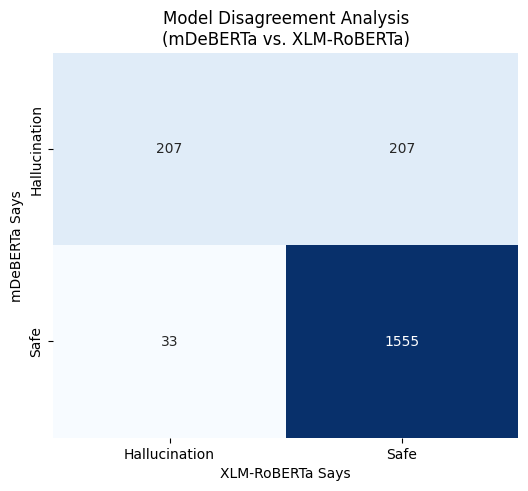


 DISAGREEMENTS (240 cases):
Cases where one model flagged an error but the other thought it was Safe.


,source,reference,hypothesis,Label_DeBERTa,Label_RoBERTa,ratio_deberta,ratio_roberta
7,එකල තම දරුවා වූ ඔහු දෙස පෙන්වූවාය.,"The she showed him, her son.",So he set down his newborn child.,Hallucination,Safe,0.777778,0.000000
8,ඔවුන් නොවටහාගන්නා ආකාරයෙන් හදිසියේම එය ඔවුන් හමුවට පැමිණෙන්නේය.,And it will come to them suddenly while they perceive [it] not.,"but the judgment shall seize upon them suddenly, whence they have no regard.",Hallucination,Safe,0.400000,0.000000
10,ඔවුන්ගේ සිත්වල කවරක් ඇත්දැයි අපි දනිමු.,We know what is in their hearts.,Allah knows best what they have therein.,Hallucination,Safe,0.272727,0.000000
29,"එක් කාන්තාවක් මට ලිව්වේ ඇයගේ අධ්‍යාත්මික මඟපෙන්වන්නාව හමුවීමට ගිය අවසන් 12 වතාවම, ඔහු අසනීප වී තිබුණු බවයි.","One woman wrote me to say that the last 12 times she's gone to see her spiritual director, he has become ill.",A woman wrote when she last saw her spiritual guide and said she found him not well during the last 12 months or so.,Hallucination,Safe,0.481481,0.000000
32,"They said: ""We stayed a day or part of a day,""","They said: ""We stayed a day or part of a day,""","They said: ""We stayed more than two centuries or part of a day,""",Hallucination,Safe,0.250000,0.100000
47,එබැවින් සුළු කාලයකට අපි ඔවුන්ව හැර දමන්නෙමු.,And so we shall leave them for a brief time.,"And so we shall hold them back for a time,",Safe,Hallucination,0.153846,0.846154
50,අයියෝ මගේ ඔළුව!,O my head!,- Give me my head!,Hallucination,Safe,0.571429,0.142857
74,ප්‍රඥාවේ වචනය මමයි.,I am the word of wisdom;,I am the word of wisdom;,Safe,Hallucination,0.125000,0.250000
99,"මෙය නව ගිවිසුමේ ක්‍රියා පදයක් නොවේ; එහි සම්බන්ධ koptô (κόπτω) නම් ක්‍රියා පදයක් ඇත [උච්චාරණය KOP-toh],","This is not a verb from the New Testament; there is the related verb koptô (κόπτω) [pronounced KOP-toh],","This is not a verb from The Marian Movement of Priests; there is the related verb koptô (κόπτω) [pronounced KOP-toh],",Hallucination,Safe,0.210526,0.000000
104,"තවද, අපි අහස ආරක්ෂා කරනු ලැබූ වියනක් ලෙස නිර්මාණය කළෙමු.",And we have made the sky a roof withheld (from them).,And we have made the sky a them withheld (from roof).,Hallucination,Safe,0.375000,0.062500


In [ ]:
# --- CELL 12: MODEL COMPARISON DASHBOARD (FIXED) ---
import seaborn as sns
pd.set_option('display.max_colwidth', None)

# 1. Check if independent labels exist
if 'Label_DeBERTa' not in df_test.columns or 'Label_RoBERTa' not in df_test.columns:
    print(" Error: Labels missing. Please run the Independent Inference cell (Cell 10) first.")
else:
    # 2. Create a Comparison Matrix (Who said what?)
    comparison_matrix = pd.crosstab(
        df_test['Label_DeBERTa'], 
        df_test['Label_RoBERTa'], 
        rownames=['mDeBERTa Says'], 
        colnames=['XLM-RoBERTa Says']
    )

    # 3. Calculate Agreement Metrics
    total = len(df_test)
    
    # Both said "Hallucination"
    both_hallucinated = len(df_test[
        (df_test['Label_DeBERTa'] == "Hallucination") & 
        (df_test['Label_RoBERTa'] == "Hallucination")
    ])
    
    # Both said "Safe"
    both_safe = len(df_test[
        (df_test['Label_DeBERTa'] == "Safe") & 
        (df_test['Label_RoBERTa'] == "Safe")
    ])
    
    # Disagreements (One said Safe, one said Hallucination)
    disagreement = total - (both_hallucinated + both_safe)
    agreement_pct = ((both_hallucinated + both_safe) / total) * 100

    # 4. Print Summary Stats
    print(f"COMPARISON DASHBOARD (Total Samples: {total})\n")
    print(f" AGREEMENT RATE: {agreement_pct:.1f}%")
    print(f"   - Both detected Hallucination: {both_hallucinated}")
    print(f"   - Both detected Safe:          {both_safe}")
    print(f"   - Disagreements:               {disagreement}")
    print("-" * 60)

    print("\n🔹 CONFUSION MATRIX (Counts):")
    display(comparison_matrix)
    print("-" * 60)

    # Define columns to display (Including Reference)
    cols = ['source', 'reference', 'hypothesis', 'Label_DeBERTa', 'Label_RoBERTa', 'ratio_deberta', 'ratio_roberta']

    # 5. Display "Confirmed" Hallucinations (Both Agree)
    # These are the most critical cases where both models found > 20% errors
    confirmed = df_test[
        (df_test['Label_DeBERTa'] == "Hallucination") & 
        (df_test['Label_RoBERTa'] == "Hallucination")
    ]
    
    if not confirmed.empty:
        print(f"\nCONFIRMED HALLUCINATIONS ({len(confirmed)} cases - Both Models Agree):")
        # Sort by highest average error ratio to show worst cases first
        confirmed['avg_error'] = (confirmed['ratio_deberta'] + confirmed['ratio_roberta']) / 2
        display(confirmed.sort_values('avg_error', ascending=False)[cols].head(10).style.background_gradient(cmap='Reds', subset=['ratio_deberta', 'ratio_roberta']))
    else:
        print("\n No Confirmed Hallucinations found.")

    # 6. Display Disagreements (Where models fought)
    disagreements = df_test[df_test['Label_DeBERTa'] != df_test['Label_RoBERTa']]

    # Instead of just print(comparison_matrix)
    plt.figure(figsize=(6, 5))
    sns.heatmap(comparison_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title("Model Disagreement Analysis\n(mDeBERTa vs. XLM-RoBERTa)")
    plt.show()

    if not disagreements.empty:
        print(f"\n DISAGREEMENTS ({len(disagreements)} cases):")
        print("Cases where one model flagged an error but the other thought it was Safe.")
        display(disagreements[cols].head(10).style.background_gradient(cmap='Blues', subset=['ratio_deberta', 'ratio_roberta']))
    else:
        print("\nNo disagreements found!")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.0 MB/s eta 0:00:00
 Calculating BERTScore (measuring semantic deviation)...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/43 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/32 [00:00<?, ?it/s]

done in 6.37 seconds, 314.16 sentences/sec
 BERTScore calculation complete.

 Average BERTScore F1 by Detector Label:
--------------------------------------------------
Label_DeBERTa
Hallucination    0.903638
Safe             0.985221
Name: bert_f1, dtype: float32
--------------------------------------------------


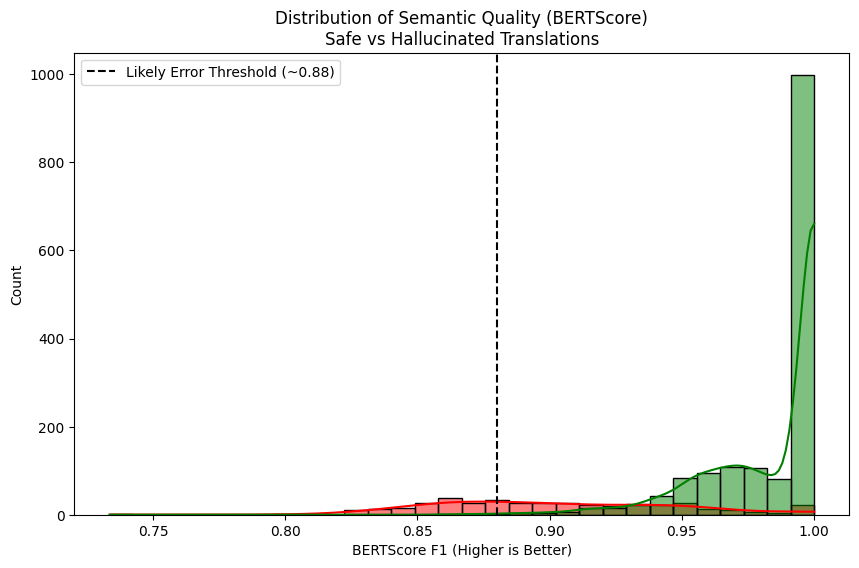


🚨 Top 5 Translations with Highest Semantic Deviation (Most Wrong):


,source,reference,hypothesis,Label_DeBERTa,bert_f1
754,"මේ පොතට අනුව,","මෙම පොතෙන්,","That article. That 's the point,",Hallucination,0.733607
1759,සබ්බා ඉත්ථියෝ - සියලු ස්ත්‍රීන්,Sabba iththiyo - All women,"He who has received the reward of the mercy of Allah, should see (on each of His companions) that they make up their backs.",Hallucination,0.796835
1070,සතුට පිරි භාග්‍යයෙන් යුත් ජන්නාහ්වන් (ස්වර්ගයන්) හි (ස්වර්ගවාසීන් වන) ඔවුහු මුහුණට මුහුණලා යහන්වල (ඇල වී) සිටිති.,They who are (the dwellers of heaven) of the Jannah (heavens) that is blissful and blessed are (lying) in beds facing each other.,And blessed shall they be on couches which shall bear straps against,Hallucination,0.799644
567,දැනුම නොමැති කමින් උන්වහන්සේට පිරිමි හා ගැහැණු දරුවන්ව ඇතිබවට උපකල්පනය කලෝය.,"In the absence of knowledge, it was assumed that He had male and female children.","Say to this world as they do: All of your hearts fail before a time of transition; thus they make for you a messengers: for that is your task, and in order that you may overcome against us a pain, a scourge not likely in the hour of transition.' (1) "" And it is your (true or false) friend?""",Hallucination,0.822421
854,"කෙසේ වෙතත්, පොලිසියෙන් (පොලිජා) හෝ නාගරික ආරක්ෂකයින්ගෙන් (ස්ට්‍රාස් මිජ්ස්කා) උදව් හෝ උපදෙස් ලබා ගැනීමට බිය නොවන්න.","In any case, do not be afraid to seek help or advice from the Police (Policja) or the Municipal Guard (Straż Miejska).","If for one point only, there might not yet be sufficient insurance to support the work carried out by those responsible, a court order or a new police notice should be issued for the workers as requested.",Hallucination,0.823359


In [ ]:
# 1. Install the evaluation library (if not already present)
!pip install -q bert_score

from bert_score import score
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Prepare Data
refs = df_test['reference'].tolist()
hyps = df_test['hypothesis'].tolist()

print(" Calculating BERTScore (measuring semantic deviation)...")

# 3. Calculate BERTScore
# We use 'roberta-large' as it is the standard for English evaluation
# lang="en" ensures it uses the correct English modeling
P, R, F1 = score(hyps, refs, lang="en", verbose=True)

# 4. Add to DataFrame
df_test['bert_f1'] = F1.numpy()

# 5. Define "Semantic Deviation"
# If BERTScore F1 is 1.0, deviation is 0. If F1 is 0.8, deviation is 0.2.
df_test['semantic_deviation'] = 1 - df_test['bert_f1']

print(" BERTScore calculation complete.")

# --- ANALYSIS: Compare Metric vs Your Detectors ---

# 6. Check the average BERTScore for "Safe" vs "Hallucination" (according to your detectors)
print("\n Average BERTScore F1 by Detector Label:")
print("-" * 50)
print(df_test.groupby('Label_DeBERTa')['bert_f1'].mean())
print("-" * 50)

# 7. Visualizing the Deviation
plt.figure(figsize=(10, 6))
sns.histplot(data=df_test, x='bert_f1', hue='Label_DeBERTa', kde=True, bins=30, palette={'Safe': 'green', 'Hallucination': 'red'})
plt.title('Distribution of Semantic Quality (BERTScore)\nSafe vs Hallucinated Translations')
plt.xlabel('BERTScore F1 (Higher is Better)')
plt.axvline(x=0.88, color='black', linestyle='--', label='Likely Error Threshold (~0.88)')
plt.legend()
plt.show()

# 8. Show the worst deviators (The most "Wrong" translations)
cols = ['source', 'reference', 'hypothesis', 'Label_DeBERTa', 'bert_f1']
print("\n🚨 Top 5 Translations with Highest Semantic Deviation (Most Wrong):")
display(df_test.sort_values('bert_f1', ascending=True)[cols].head(5))

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.4/101.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 86.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.7/529.7 kB 32.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.22.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not i

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

checkpoints/model.ckpt:   0%|          | 0.00/2.32G [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/core/saving.py:197: Found keys that are not in the model state dict but in the checkpoint: ['encoder.model.embeddings.position_ids']
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(tr

,source,hypothesis,reference,label,method,tokens_deberta,tokens_roberta,hyp_length,ratio_deberta,ratio_roberta,Label_DeBERTa,Label_RoBERTa,bert_f1,semantic_deviation,comet_score
1964,"ඔබ වැරදි නම්, අප ඔබව නැවත පුහුණු කරන්නෙමු.","The day after the election this month, we should hold the vote for the President and nominate four prime minister, on his own initiative?","If you are wrong, we will retrain you.",1,temp,29,28,29,1.000000,0.965517,Hallucination,Hallucination,0.850466,0.149534,0.385109
1759,සබ්බා ඉත්ථියෝ - සියලු ස්ත්‍රීන්,"He who has received the reward of the mercy of Allah, should see (on each of His companions) that they make up their backs.",Sabba iththiyo - All women,1,temp,36,30,36,1.000000,0.833333,Hallucination,Hallucination,0.796835,0.203165,0.394868
134,ඕක මුලින්ම තේරුම් ගත්තේ අපේ [පහවත් පාස් නැති] ජාතියේ පියා.,Or if your father's in control of a family... do you?,The first one who got it was our nation's father [who hadn't even passed grade five].,1,temp,16,15,16,1.000000,0.937500,Hallucination,Hallucination,0.831011,0.168989,0.403630
626,එවිට මිනිසුන්ට ආහාට ලැබෙන විට ඔවුන් දෙස බලන්න. .,"Then when they get along in a hurry, they'll check them out..","and look at the people when they receive their food,",1,temp,14,15,24,0.583333,0.625000,Hallucination,Hallucination,0.862077,0.137923,0.415677
125,ඇපල් සහ කැලිෆෝනියා විශ්ව විද්‍යාලය මානසික සෞඛ්‍යය අධ්‍යයනය කරයි.,"As far back as the s.a.'ll be over, there are three main reasons for an increasing risk:",Apple and the University of California study mental health.,1,temp,28,23,28,1.000000,0.821429,Hallucination,Hallucination,0.827343,0.172657,0.416584


COMET calculation complete.


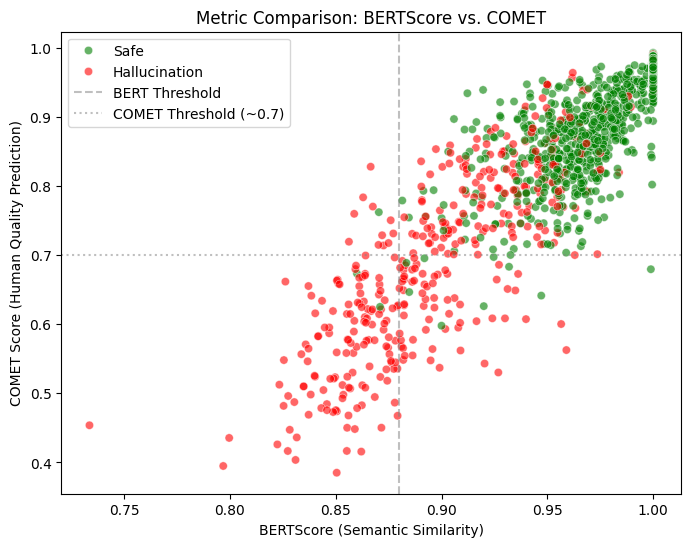


 Low Quality Translations (COMET < 0.7):


,source,hypothesis,reference,bert_f1,comet_score,Label_DeBERTa
1964,"ඔබ වැරදි නම්, අප ඔබව නැවත පුහුණු කරන්නෙමු.","The day after the election this month, we should hold the vote for the President and nominate four prime minister, on his own initiative?","If you are wrong, we will retrain you.",0.850466,0.385109,Hallucination
1759,සබ්බා ඉත්ථියෝ - සියලු ස්ත්‍රීන්,"He who has received the reward of the mercy of Allah, should see (on each of His companions) that they make up their backs.",Sabba iththiyo - All women,0.796835,0.394868,Hallucination
134,ඕක මුලින්ම තේරුම් ගත්තේ අපේ [පහවත් පාස් නැති] ජාතියේ පියා.,Or if your father's in control of a family... do you?,The first one who got it was our nation's father [who hadn't even passed grade five].,0.831011,0.403630,Hallucination
626,එවිට මිනිසුන්ට ආහාට ලැබෙන විට ඔවුන් දෙස බලන්න. .,"Then when they get along in a hurry, they'll check them out..","and look at the people when they receive their food,",0.862077,0.415677,Hallucination
125,ඇපල් සහ කැලිෆෝනියා විශ්ව විද්‍යාලය මානසික සෞඛ්‍යය අධ්‍යයනය කරයි.,"As far back as the s.a.'ll be over, there are three main reasons for an increasing risk:",Apple and the University of California study mental health.,0.827343,0.416584,Hallucination


In [ ]:
# 1. Install COMET
# Note: This might require a restart of the kernel if dependencies conflict
!pip install -q unbabel-comet
from comet import download_model, load_from_checkpoint

print("Loading COMET model...")
model_path = download_model("Unbabel/wmt22-comet-da")
comet_model = load_from_checkpoint(model_path)  

comet_data = [
    {"src": r['source'], "mt": r['hypothesis'], "ref": r['reference']}
    for _, r in df_test.iterrows()
]

model_output = comet_model.predict(comet_data, batch_size=8, gpus=1)
df_test['comet_score'] = model_output.scores

display(df_test.sort_values('comet_score').head())

print("COMET calculation complete.")

import matplotlib.pyplot as plt
import seaborn as sns

# 6. Correlation Analysis
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_test, x='bert_f1', y='comet_score', hue='Label_DeBERTa', palette={'Safe': 'green', 'Hallucination': 'red'}, alpha=0.6)
plt.title('Metric Comparison: BERTScore vs. COMET')
plt.xlabel('BERTScore (Semantic Similarity)')
plt.ylabel('COMET Score (Human Quality Prediction)')
plt.axvline(x=0.88, color='grey', linestyle='--', alpha=0.5, label='BERT Threshold')
plt.axhline(y=0.7, color='grey', linestyle=':', alpha=0.5, label='COMET Threshold (~0.7)')
plt.legend()
plt.show()

# 7. Show "High Confidence" Hallucinations (Low COMET, High Detector Agreement)
print("\n Low Quality Translations (COMET < 0.7):")
low_quality = df_test[df_test['comet_score'] < 0.7].sort_values('comet_score')
cols = ['source', 'hypothesis', 'reference', 'bert_f1', 'comet_score', 'Label_DeBERTa']
display(low_quality[cols].head(5))

In [ ]:
import pandas as pd

# --- 1. Save BERTScore Report ---
# Checks if you have calculated BERTScore first
if 'bert_f1' in df_test.columns:
    print(" Saving BERTScore Report...")
    
    # Select relevant columns for semantic analysis
    bert_cols = [
        'source', 
        'reference', 
        'hypothesis', 
        'Label_DeBERTa',     
        'bert_f1',          
        'semantic_deviation'  
    ]
    
    # Save to Excel
    df_test[bert_cols].to_excel("bert_score_semantic_report.xlsx", index=False)
    print("Saved 'bert_score_semantic_report.xlsx'")
else:
    print("BERTScore columns not found. Did you run the BERTScore calculation cell?")
print("-" * 30)

# --- 2. Save COMET Report ---
if 'comet_score' in df_test.columns:
    print("Saving COMET Report...")
    
    comet_cols = [
        'source', 
        'reference', 
        'hypothesis', 
        'Label_DeBERTa', 
        'comet_score'         
    ]
    
    # Save to Excel
    df_test[comet_cols].to_excel("comet_quality_report.xlsx", index=False)
    print("Saved 'comet_quality_report.xlsx'")
else:
    print("COMET columns not found. Did you run the COMET calculation cell?")

 Saving BERTScore Report...
Saved 'bert_score_semantic_report.xlsx'
------------------------------
Saving COMET Report...
Saved 'comet_quality_report.xlsx'


## 5. Metric Validation: Semantic & Quality Analysis
To validate our binary "Safe/Hallucination" labels, we use two industry-standard metrics:
1.  **BERTScore:** Measures semantic similarity. (How close is the *meaning*?)
2.  **COMET:** Predicts human quality judgments. (Is the translation *good*?)

**Hypothesis:** Translations flagged as **"Hallucinations"** by our model should have significantly lower BERTScore and COMET scores than those flagged as **"Safe"**.

Calculating BERTScore (measuring semantic deviation)...


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


  0%|          | 0/43 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/32 [00:00<?, ?it/s]

done in 6.39 seconds, 313.40 sentences/sec
BERTScore calculation complete.



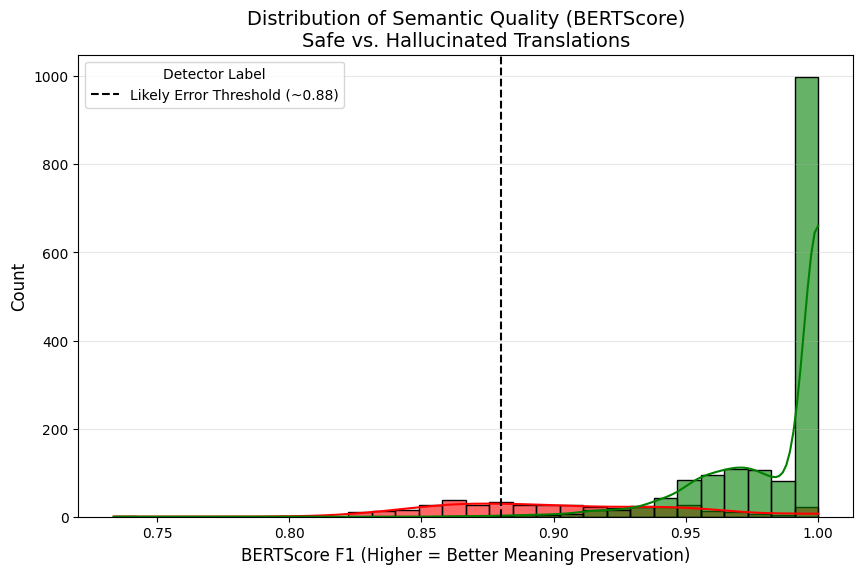

Average BERTScore F1 by Detector Label:
----------------------------------------
Label_DeBERTa
Hallucination    0.903638
Safe             0.985221
Name: bert_f1, dtype: float32
----------------------------------------


In [ ]:
from bert_score import score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare Data
refs = df_test['reference'].tolist()
hyps = df_test['hypothesis'].tolist()

print("Calculating BERTScore (measuring semantic deviation)...")

# 2. Calculate BERTScore
# We use 'roberta-large' (default for English) to capture deep semantic meaning
# The metric returns Precision, Recall, and F1. We care most about F1.
P, R, F1 = score(hyps, refs, lang="en", verbose=True)

# 3. Add to DataFrame
df_test['bert_f1'] = F1.numpy()
df_test['semantic_deviation'] = 1 - df_test['bert_f1'] # Flip score for "Error" magnitude

print("BERTScore calculation complete.\n")


plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_test, 
    x='bert_f1', 
    hue='Label_DeBERTa', 
    kde=True, 
    bins=30, 
    palette={'Safe': 'green', 'Hallucination': 'red'},
    alpha=0.6
)

plt.title('Distribution of Semantic Quality (BERTScore)\nSafe vs. Hallucinated Translations', fontsize=14)
plt.xlabel('BERTScore F1 (Higher = Better Meaning Preservation)', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add a threshold line for visual reference
plt.axvline(x=0.88, color='black', linestyle='--', label='Likely Error Threshold (~0.88)')
plt.legend(title='Detector Label')
plt.grid(axis='y', alpha=0.3)

plt.show()

# Print stats
print("Average BERTScore F1 by Detector Label:")
print("-" * 40)
print(df_test.groupby('Label_DeBERTa')['bert_f1'].mean())
print("-" * 40)